<a href="https://colab.research.google.com/github/adilaw-p/PINNs-for-2D-steady-state-heat-conduction/blob/main/PINN-for-2D-steady-state-heat-condition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Geometry**

Connecting to Google Drive...
Mounted at /content/drive
Google Drive connected successfully!
Folder '/content/drive/MyDrive/PROJECT_1/generated_geometry' created in Drive.

Starting Geometry Generation

Generating Solid Geometry
Complete: Actual Porosity: 0.00%
Saved at: /content/drive/MyDrive/PROJECT_1/generated_geometry/solid_matrix_geo_p0.000.npy


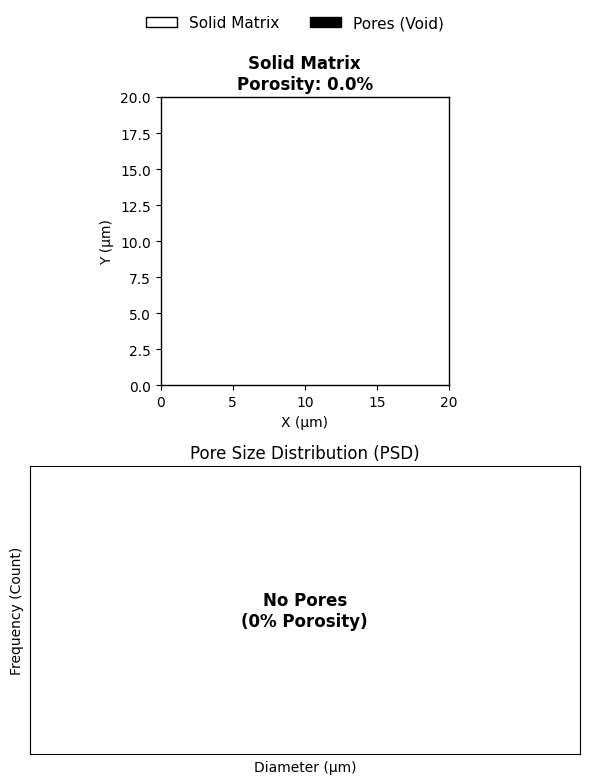


All processes completed. File 'solid_matrix_geo_p0.000.npy' has been saved to Google Drive.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# MOUNT GOOGLE DRIVE
print("Connecting to Google Drive...")
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive connected successfully!")
except ImportError:
    print("You are not in Google Colab. Saving locally.")

# CONFIGURATION & FOLDER PATH
BASE_PATH = "/content/drive/MyDrive/PROJECT_1"
OUTPUT_FOLDER = os.path.join(BASE_PATH, "generated_geometry")
GRID_SIZE = 256
DOMAIN_SIZE_UM = 20.0  # Generic domain size in micrometers
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)
    print(f"Folder '{OUTPUT_FOLDER}' created in Drive.")
else:
    print(f"Folder '{OUTPUT_FOLDER}' already exists in Drive.")

# GENERATOR FUNCTION
def generate_solid_mask(grid_size):
    print(f"\nGenerating Solid Geometry")

    # Create a completely solid matrix (array filled with 1s)
    mask = np.ones((grid_size, grid_size), dtype=np.float32)
    actual_porosity = 0.0
    filename = f"solid_matrix_geo_p{actual_porosity:.3f}.npy"
    save_path = os.path.join(OUTPUT_FOLDER, filename)

    np.save(save_path, mask)

    print(f"Complete: Actual Porosity: {actual_porosity*100:.2f}%")
    print(f"Saved at: {save_path}")
    return mask, actual_porosity, filename

# EXECUTION & VISUALIZATION
fig, axes = plt.subplots(2, 1, figsize=(6, 7.5), squeeze=False)
print("\nStarting Geometry Generation")
mask_res, act_por, fname = generate_solid_mask(GRID_SIZE)

# 1. GEOMETRY STRUCTURE VISUALIZATION
ax_geo = axes[0, 0]
ax_geo.imshow(mask_res, origin='lower', cmap='gray', extent=[0, DOMAIN_SIZE_UM, 0, DOMAIN_SIZE_UM], vmin=0, vmax=1)
ax_geo.set_title(f"Solid Matrix\nPorosity: {act_por*100:.1f}%", fontweight='bold')
ax_geo.axis('on')
ax_geo.set_xlabel("X (µm)")
ax_geo.set_ylabel("Y (µm)")

for spine in ax_geo.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.0)

# 2. HISTOGRAM VISUALIZATION (EMPTY)
ax_hist = axes[1, 0]
# Display text instead of a graph since there are no pores
ax_hist.text(0.5, 0.5, "No Pores\n(0% Porosity)", ha='center', va='center', fontsize=12, fontweight='bold', transform=ax_hist.transAxes)
ax_hist.set_title("Pore Size Distribution (PSD)")
ax_hist.set_xlabel("Diameter (µm)")
ax_hist.set_ylabel("Frequency (Count)")
ax_hist.set_xlim(0, 10)  # Arbitrary limits for visual structure
ax_hist.set_ylim(0, 10)
ax_hist.set_xticks([])
ax_hist.set_yticks([])

# GLOBAL LEGEND
solid_patch = mpatches.Patch(color='white', label='Solid Matrix', ec='black', lw=1)
pore_patch = mpatches.Patch(color='black', label='Pores (Void)', ec='black', lw=1)

fig.legend(handles=[solid_patch, pore_patch],
           loc='upper center',
           ncol=2,
           fontsize=11,
           bbox_to_anchor=(0.5, 1.05),
           frameon=False)

plt.tight_layout()
plt.show()
print(f"\nAll processes completed. File '{fname}' has been saved to Google Drive.")

#**PINN code for steady-state heat conduction**

Connecting to Google Drive
Google Drive is already mounted.
SIMULATION CONFIGURATION (OPTIMIZED)
Device in use: cuda
Geometry File in use: solid_matrix_geo_p0.000.npy

Training Initialization (Optimized)
Starting Phase 1: ADAM (3500 epochs)...
Ep 0: Total 2.0939e+04 | PDE 1.0355e+03 | BC 2.3025e+00 | LR 1.0e-03
Ep 350: Total 1.7652e+01 | PDE 8.1375e-01 | BC 1.3770e-02 | LR 9.3e-04
Ep 700: Total 5.9932e+00 | PDE 2.8799e-01 | BC 2.3342e-03 | LR 8.7e-04
Ep 1050: Total 3.1903e+00 | PDE 1.5496e-01 | BC 9.1097e-04 | LR 8.1e-04
Ep 1400: Total 2.0442e+00 | PDE 9.9703e-02 | BC 5.0132e-04 | LR 7.6e-04
Ep 1750: Total 1.4464e+00 | PDE 7.0701e-02 | BC 3.2351e-04 | LR 7.0e-04
Ep 2100: Total 1.0875e+00 | PDE 5.3238e-02 | BC 2.2771e-04 | LR 6.6e-04
Ep 2450: Total 8.5143e-01 | PDE 4.1724e-02 | BC 1.6945e-04 | LR 6.1e-04
Ep 2800: Total 6.8581e-01 | PDE 3.3635e-02 | BC 1.3109e-04 | LR 5.7e-04
Ep 3150: Total 5.6401e-01 | PDE 2.7679e-02 | BC 1.0429e-04 | LR 5.3e-04

Starting Phase 2: L-BFGS (Max 1500 iter)

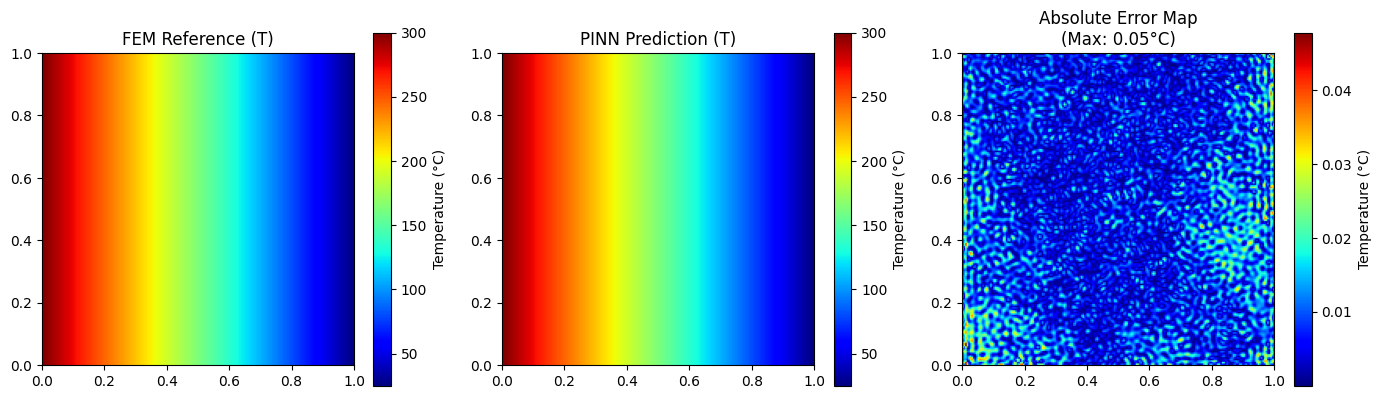


Generating Heat Flux Comparison Plots


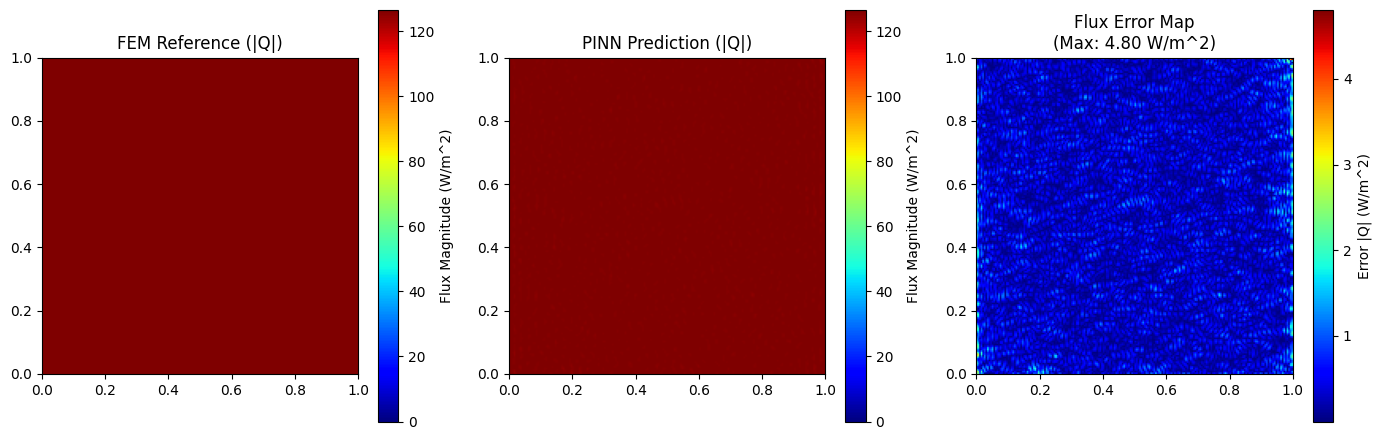

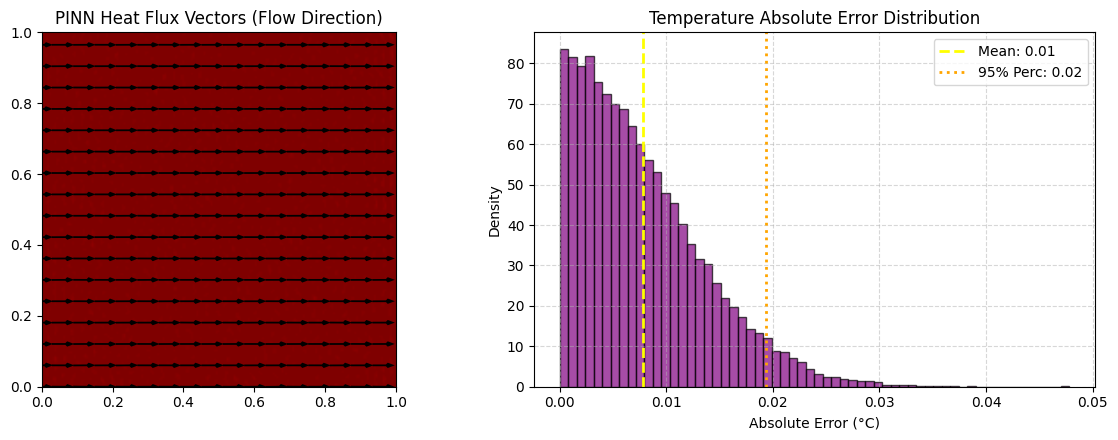


Generating Loss History Plot


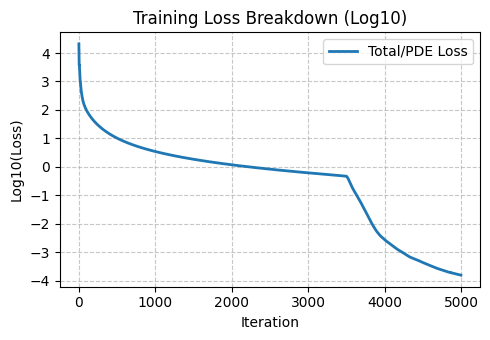


EMT Validation (Effective Medium Theory)
Porosity       : 0.00%
K_eff Theory   : 0.46000
K_eff PINN     : 0.46000
K_eff FEM      : 0.46000
Error EMT      : 0.00%
Error FEM-ME   : 0.00%

Generating K_eff vs Porosity Validation Graph


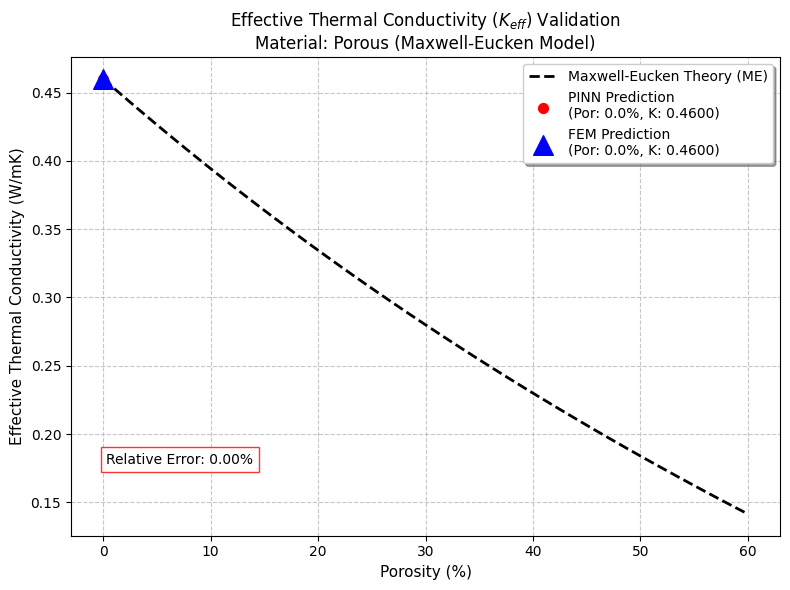


Generating 1D Temperature Profile Plots


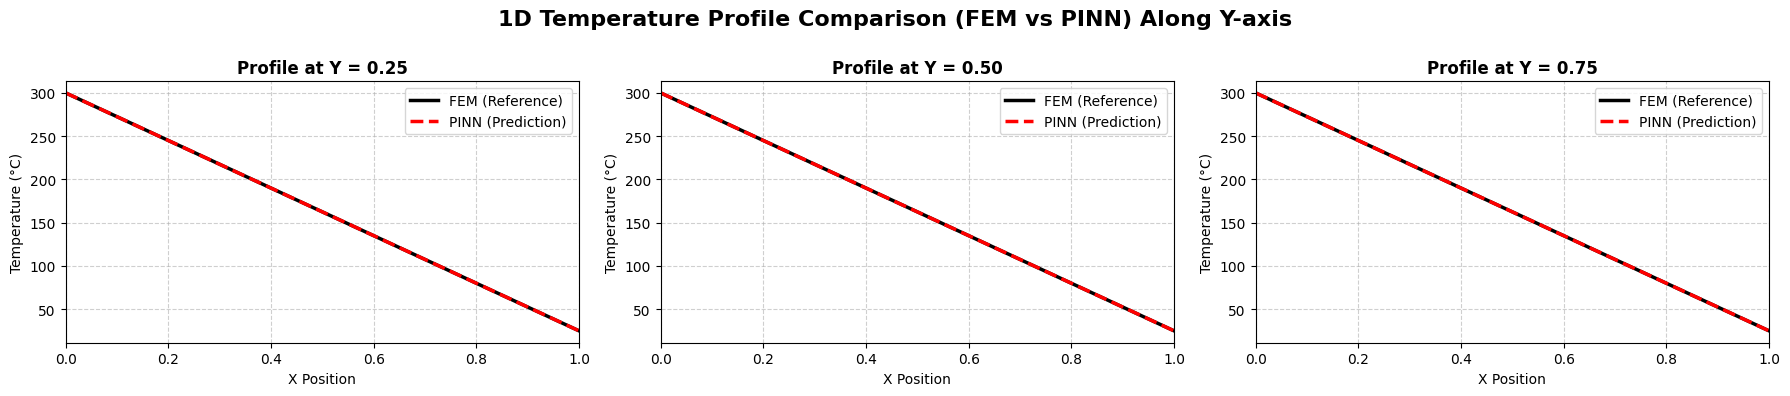

Combined Visualization Rendering Time (PINN & FEM): 2.7247 seconds


In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.sparse import csr_matrix, coo_matrix
from scipy.sparse.linalg import spsolve
from torch.nn.init import xavier_uniform_
from scipy.optimize import fsolve
from scipy.ndimage import gaussian_filter
import os
import glob
import time

# MOUNT GOOGLE DRIVE (ACCESS PREVIOUS GEOMETRIES)
print("Connecting to Google Drive")
try:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
        print("Google Drive connected successfully!")
    else:
        print("Google Drive is already mounted.")
    FOLDER_MASK = "/content/drive/MyDrive/PROJECT_1/generated_geometry"
except ImportError:
    print("You are not in Google Colab. Using local directory.")
    FOLDER_MASK = "generated_masks"

# SECTION 0: GLOBAL CONFIGURATION & PHYSICAL PARAMETERS
print("SIMULATION CONFIGURATION (OPTIMIZED)")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

SELECTED_FILE_INDEX = 0

T_HOT = 300.0
T_COLD = 25.0
DELTA_T = T_HOT - T_COLD
K_SOLID = 0.46
K_VOID = 0.0267
MATERIAL_CODE = "Z"
PORE_SIZE_CODE = "k"

# SECTION 1: LOAD GEOMETRY (0% POROSITY / FULL SOLID)
target_filename = "solid_matrix_geo_p0.000.npy"
SELECTED_GEO_FILE = os.path.join(FOLDER_MASK, target_filename)

if not os.path.exists(SELECTED_GEO_FILE):
    print(f"{FOLDER_MASK}...")
    alt_files = glob.glob(os.path.join(FOLDER_MASK, "solid_matrix_geo_p*.npy"))
    if alt_files:
        SELECTED_GEO_FILE = alt_files[0]
        print(f"{os.path.basename(SELECTED_GEO_FILE)}")
    else:
        raise FileNotFoundError(f"File '{target_filename}'not found '{FOLDER_MASK}'!.")

print(f"Geometry File in use: {os.path.basename(SELECTED_GEO_FILE)}")

def load_selected_geometry(file_path):
    mask_ori = np.load(file_path)
    mask_smoothed = gaussian_filter(mask_ori.astype(float), sigma=0.8)
    return mask_smoothed, mask_ori

solid_mask_smoothed, solid_mask_ori = load_selected_geometry(SELECTED_GEO_FILE)
H_GRID, W_GRID = solid_mask_smoothed.shape

# SECTION 2: DATA PREPARATION
x_lin = np.linspace(0, 1, W_GRID)
y_lin = np.linspace(0, 1, H_GRID)
mask_interpolator = RegularGridInterpolator((x_lin, y_lin), solid_mask_smoothed.T, method='linear')

def get_conductivity(x, y):
    points = torch.cat([x, y], axis=1).detach().cpu().numpy()
    mask_vals = mask_interpolator(points)
    mask_tensor = torch.tensor(mask_vals, dtype=torch.float32, device=device).unsqueeze(1)
    k = K_VOID + mask_tensor * (K_SOLID - K_VOID)
    return k

# SECTION 3: PINN ARCHITECTURE
class PhysicsInformedNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.B = torch.randn(2, 64) * 5.0
        self.register_buffer('B_freq', self.B)
        self.net = nn.Sequential(
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 3)
        )
        self.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            xavier_uniform_(m.weight)
            m.bias.data.fill_(0.0)

    def forward(self, x, y):
        inputs = torch.cat([x, y], axis=1)
        proj = 2 * np.pi * (inputs @ self.B_freq)
        inputs_embed = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        output = self.net(inputs_embed)
        return output[:, 0:1], output[:, 1:2], output[:, 2:3]

# SECTION 4: PHYSICS LOSS DEFINITION
def physics_loss(model, x, y):
    x.requires_grad = True
    y.requires_grad = True

    T_pred, Qx_pred, Qy_pred = model(x, y)
    k_val = get_conductivity(x, y).detach()

    dT_dx = torch.autograd.grad(T_pred, x, grad_outputs=torch.ones_like(T_pred), create_graph=True)[0]
    dT_dy = torch.autograd.grad(T_pred, y, grad_outputs=torch.ones_like(T_pred), create_graph=True)[0]
    dQx_dx = torch.autograd.grad(Qx_pred, x, grad_outputs=torch.ones_like(Qx_pred), create_graph=True)[0]
    dQy_dy = torch.autograd.grad(Qy_pred, y, grad_outputs=torch.ones_like(Qy_pred), create_graph=True)[0]

    res_Qx = Qx_pred + k_val * dT_dx
    res_Qy = Qy_pred + k_val * dT_dy
    loss_constitutive = torch.mean(res_Qx**2) + torch.mean(res_Qy**2)

    res_div = dQx_dx + dQy_dy
    loss_continuity = torch.mean(res_div**2)

    return loss_constitutive, loss_continuity

# SECTION 5: TRAINING LOOP
print(f"\nTraining Initialization (Optimized)")

N_COL_1D = 200
N_BOUNDARY = 800

x_c = torch.linspace(0, 1, N_COL_1D); y_c = torch.linspace(0, 1, N_COL_1D)
X_c, Yc = torch.meshgrid(x_c, y_c, indexing='ij')
x_col = X_c.flatten()[:, None].to(device)
y_col = Yc.flatten()[:, None].to(device)

xb = torch.linspace(0, 1, N_BOUNDARY // 4, device=device).reshape(-1, 1)
x_left = torch.zeros_like(xb); y_left = xb
x_right = torch.ones_like(xb); y_right = xb
x_top = xb; y_top = torch.ones_like(xb)
x_btm = xb; y_btm = torch.zeros_like(xb)

model = PhysicsInformedNN().to(device)

W_PDE = 20.0
W_BC  = 100.0

loss_history = []
loss_pde_history = []
loss_bc_history = []

def closure_loss(optimizer=None):
    if optimizer: optimizer.zero_grad()

    l_const, l_cont = physics_loss(model, x_col, y_col)

    T_l,_,_ = model(x_left, y_left);   l_bc_l = torch.mean((T_l - 1.0)**2)
    T_r,_,_ = model(x_right, y_right); l_bc_r = torch.mean((T_r - 0.0)**2)
    _,_,Qy_t = model(x_top, y_top);    l_bc_t = torch.mean(Qy_t**2)
    _,_,Qy_b = model(x_btm, y_btm);    l_bc_b = torch.mean(Qy_b**2)
    l_bc = l_bc_l + l_bc_r + l_bc_t + l_bc_b

    loss_pde = l_const + l_cont
    total_loss = (W_PDE * loss_pde) + (W_BC * l_bc)

    if optimizer: total_loss.backward()
    return total_loss, loss_pde, l_bc

# PHASE 1: ADAM
ADAM_EPOCHS = 3500
optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer_adam, gamma=0.9998)

print(f"Starting Phase 1: ADAM ({ADAM_EPOCHS} epochs)...")
start_time = time.time()

for epoch in range(ADAM_EPOCHS):
    loss, lpde, lbc = closure_loss(optimizer_adam)
    optimizer_adam.step()
    scheduler.step()

    loss_history.append(loss.item())
    loss_pde_history.append(lpde.item())
    loss_bc_history.append(lbc.item())

    if epoch % 350 == 0:
        print(f"Ep {epoch}: Total {loss.item():.4e} | PDE {lpde.item():.4e} | BC {lbc.item():.4e} | LR {scheduler.get_last_lr()[0]:.1e}")

# PHASE 2: L-BFGS
print(f"\nStarting Phase 2: L-BFGS (Max 1500 iter)...")
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0, max_iter=1500, max_eval=1500, history_size= 500,
    tolerance_grad=1e-7, tolerance_change=1e-9, line_search_fn="strong_wolfe"
)

def closure_lbfgs_wrapper():
    optimizer_lbfgs.zero_grad()
    total_loss, l_pde, l_bc = closure_loss(optimizer=None)
    total_loss.backward()

    if not hasattr(closure_lbfgs_wrapper, "iter_count"): closure_lbfgs_wrapper.iter_count = 0
    closure_lbfgs_wrapper.iter_count += 1

    current_pde = l_pde.item()
    loss_history.append(total_loss.item())
    loss_pde_history.append(l_pde.item())
    loss_bc_history.append(l_bc.item())

    if closure_lbfgs_wrapper.iter_count % 500 == 0:
        print(f"L-BFGS {closure_lbfgs_wrapper.iter_count}: Total {total_loss.item():.5e} | PDE {current_pde:.5e}")

    return total_loss

closure_lbfgs_wrapper.iter_count = 0
optimizer_lbfgs.step(closure_lbfgs_wrapper)

end_time = time.time()
pinn_compute_time = end_time - start_time
print(f"Training Complete. Total PINN Training Time: {pinn_compute_time/60:.2f} minutes")

lc, lcont = physics_loss(model, x_col, y_col)
final_pde_res = lc.item() + lcont.item()

print(f"\nFINAL CHECK")
print(f"Total PDE Residual: {final_pde_res:.6e}")
if final_pde_res < 1e-4:
    print("Model SUCCESS (Physically consistent)")
else:
    print("Model has not fully converged (<1e-4).")

# SECTION 6: FEM VALIDATION & ERROR ANALYSIS
print(f"\nNumerical Validation (FEM)")

def solve_fem(N_grid):
    t_mesh_start = time.time()

    M = N_grid
    x_fem = np.linspace(0, 1, M)
    y_fem = np.linspace(0, 1, M)
    X, Y = np.meshgrid(x_fem, y_fem)

    num_nodes = M * M
    node_idx = np.arange(num_nodes).reshape(M, M)

    n1 = node_idx[:-1, :-1].flatten()
    n2 = node_idx[:-1, 1:].flatten()
    n3 = node_idx[1:, 1:].flatten()
    n4 = node_idx[1:, :-1].flatten()

    elements = np.stack([n1, n2, n3, n4], axis=1)

    xc = (X[:-1, :-1] + X[1:, 1:]) / 2.0
    yc = (Y[:-1, :-1] + Y[1:, 1:]) / 2.0
    pts_c = np.stack([xc.flatten(), yc.flatten()], axis=1)

    mask_ori_interpolator = RegularGridInterpolator((x_lin, y_lin), solid_mask_ori.T, method='linear')
    K_flat = K_VOID + mask_ori_interpolator(pts_c) * (K_SOLID - K_VOID)

    K_base = (1.0 / 6.0) * np.array([
        [ 4.0, -1.0, -2.0, -1.0],
        [-1.0,  4.0, -1.0, -2.0],
        [-2.0, -1.0,  4.0, -1.0],
        [-1.0, -2.0, -1.0,  4.0]
    ])

    I = np.repeat(elements, 4, axis=1).flatten()
    J = np.tile(elements, (1, 4)).flatten()
    V = (K_flat[:, None, None] * K_base).flatten()

    K_global = coo_matrix((V, (I, J)), shape=(num_nodes, num_nodes)).tolil()
    F_global = np.zeros(num_nodes)

    left_nodes = node_idx[:, 0]
    right_nodes = node_idx[:, -1]

    for n in left_nodes:
        K_global[n, :] = 0.0; K_global[n, n] = 1.0; F_global[n] = T_HOT
    for n in right_nodes:
        K_global[n, :] = 0.0; K_global[n, n] = 1.0; F_global[n] = T_COLD

    t_mesh_end = time.time()
    mesh_time = t_mesh_end - t_mesh_start

    t_solve_start = time.time()
    T_flat = spsolve(K_global.tocsr(), F_global)
    t_solve_end = time.time()
    solve_time = t_solve_end - t_solve_start

    return T_flat.reshape(M, M), K_flat, mesh_time, solve_time

N_VAL = 200

print(f"Running FEM solver (Q4 Element) with resolution {N_VAL}x{N_VAL}...")
start_fem_time = time.time()
T_ref, K_flat_fem, fem_mesh_time, fem_solve_time = solve_fem(N_VAL)
end_fem_time = time.time()

fem_compute_time = end_fem_time - start_fem_time
print(f"FEM Mesh & Matrix Setup Time: {fem_mesh_time:.4f} seconds")
print(f"FEM Solver Time (spsolve): {fem_solve_time:.4f} seconds")
print(f"Total FEM Execution Time: {fem_compute_time:.4f} seconds")

# 1. FEM HEAT FLUX CALCULATION
dx = 1.0 / (N_VAL - 1)
x_val = np.linspace(0, 1, N_VAL)
y_val = np.linspace(0, 1, N_VAL)
X_val, Y_val = np.meshgrid(x_val, y_val)

pts_n = np.stack([X_val.flatten(), Y_val.flatten()], axis=1)
mask_ori_interpolator_n = RegularGridInterpolator((x_lin, y_lin), solid_mask_ori.T, method='nearest')
K_nodes = K_VOID + mask_ori_interpolator_n(pts_n) * (K_SOLID - K_VOID)
K_nodes = K_nodes.reshape(N_VAL, N_VAL)

dT_dy_n, dT_dx_n = np.gradient(T_ref, dx, dx)
Qx_fem_full = -K_nodes * dT_dx_n
Qy_fem_full = -K_nodes * dT_dy_n
Flux_Mag_fem = np.sqrt(Qx_fem_full**2 + Qy_fem_full**2)

xc_fem = (X_val[:-1, :-1] + X_val[1:, 1:]) / 2.0
yc_fem = (Y_val[:-1, :-1] + Y_val[1:, 1:]) / 2.0
pts_elem = np.stack([xc_fem.flatten(), yc_fem.flatten()], axis=1)
K_elem_flat = K_VOID + mask_ori_interpolator_n(pts_elem) * (K_SOLID - K_VOID)
K_elem = K_elem_flat.reshape(N_VAL-1, N_VAL-1)

T_right = 0.5 * (T_ref[1:, 1:] + T_ref[:-1, 1:])
T_left = 0.5 * (T_ref[1:, :-1] + T_ref[:-1, :-1])
dT_dx_elem = (T_right - T_left) / dx
qx_elem_fem = -K_elem * dT_dx_elem

Q_avg_fem = float(np.mean(qx_elem_fem))
lambda_fem = Q_avg_fem / DELTA_T

# 2. PINN INFERENCE TIME (T & FLUX)
xv = torch.tensor(X_val.flatten()[:,None], dtype=torch.float32, device=device)
yv = torch.tensor(Y_val.flatten()[:,None], dtype=torch.float32, device=device)

model.eval()
start_pinn_infer = time.time()
with torch.no_grad():
    T_p_norm, _, _ = model(xv, yv)
end_pinn_infer = time.time()
pinn_infer_time = end_pinn_infer - start_pinn_infer
print(f"PINN Inference Time (Grid {N_VAL}x{N_VAL}): {pinn_infer_time:.4f} seconds")

T_pred = (T_p_norm.cpu().numpy().reshape(N_VAL, N_VAL) * DELTA_T) + T_COLD

# 3. DISCRETE PINN HEAT FLUX CALCULATION
dT_dy_pinn, dT_dx_pinn = np.gradient(T_pred, dx, dx)
Qx_pinn_full = -K_nodes * dT_dx_pinn
Qy_pinn_full = -K_nodes * dT_dy_pinn
Flux_Mag_pinn = np.sqrt(Qx_pinn_full**2 + Qy_pinn_full**2)

T_right_p = 0.5 * (T_pred[1:, 1:] + T_pred[:-1, 1:])
T_left_p = 0.5 * (T_pred[1:, :-1] + T_pred[:-1, :-1])
dT_dx_elem_p = (T_right_p - T_left_p) / dx
qx_elem_pinn = -K_elem * dT_dx_elem_p

Q_avg_pinn = float(np.mean(qx_elem_pinn))
lambda_pinn_discrete = Q_avg_pinn / DELTA_T

# 4. TEMPERATURE ERROR METRICS
diff = T_pred - T_ref
mse = np.mean(diff**2)
rmse = np.sqrt(mse)
l2_rel = np.linalg.norm(diff) / np.linalg.norm(T_ref)
max_abs_err = np.max(np.abs(diff))
mean_abs_err = np.mean(np.abs(diff))
mape = np.mean(np.abs(diff / T_ref)) * 100
std_err = np.std(diff)

# 5. HEAT FLUX ERROR METRICS
diff_q = Flux_Mag_fem - Flux_Mag_pinn
mse_q = np.mean(diff_q**2)
rmse_q = np.sqrt(mse_q)
l2_rel_q = np.linalg.norm(diff_q) / np.linalg.norm(Flux_Mag_fem)

max_flux_fem = np.max(Flux_Mag_fem)
max_flux_pinn = np.max(Flux_Mag_pinn)

print(f"\n--- TEMPERATURE METRICS ---")
print(f"MSE Error          : {mse:.4e}")
print(f"RMSE Error         : {rmse:.4f} °C")
print(f"L2 Relative Error  : {l2_rel:.4e} ({l2_rel*100:.3f}%)")
print(f"MAPE               : {mape:.4f} %")
print(f"Max Abs Error      : {max_abs_err:.4f} °C")
print(f"Std Dev Error      : {std_err:.4f} °C")

print(f"\n--- HEAT FLUX METRICS ---")
print(f"Average Heat Flux FEM  : {Q_avg_fem:.4f} W/m^2")
print(f"Average Heat Flux PINN : {Q_avg_pinn:.4f} W/m^2")
print(f"Max Heat Flux FEM        : {max_flux_fem:.4f} W/m^2")
print(f"Max Heat Flux PINN       : {max_flux_pinn:.4f} W/m^2")
print(f"MSE Flux                 : {mse_q:.4e}")
print(f"RMSE Flux                : {rmse_q:.4f} W/m^2")
print(f"L2 Relative Flux         : {l2_rel_q:.4e} ({l2_rel_q*100:.3f}%)")

# SECTION 7: FULL VISUALIZATION
start_vis_time = time.time()

skip_vec = 12
x_q = X_val[::skip_vec, ::skip_vec]
y_q = Y_val[::skip_vec, ::skip_vec]
Qx_q = Qx_pinn_full[::skip_vec, ::skip_vec]
Qy_q = Qy_pinn_full[::skip_vec, ::skip_vec]

mask_val_interpolator = RegularGridInterpolator((x_lin, y_lin), solid_mask_smoothed.T, method='linear')
pts_val = np.stack([X_val.flatten(), Y_val.flatten()], axis=1)
mask_val = mask_val_interpolator(pts_val).reshape(N_VAL, N_VAL)

# 7.1 Temperature Plots
print(f"\nGenerating Temperature Visualization Plots")
fig1, ax1 = plt.subplots(1, 3, figsize=(14, 4))
im0 = ax1[0].imshow(T_ref, origin='lower', extent=[0,1,0,1], cmap='jet')
ax1[0].set_title('FEM Reference (T)')
plt.colorbar(im0, ax=ax1[0], label='Temperature (°C)')

im1 = ax1[1].imshow(T_pred, origin='lower', extent=[0,1,0,1], cmap='jet')
ax1[1].set_title('PINN Prediction (T)')
plt.colorbar(im1, ax=ax1[1], label='Temperature (°C)')

im2 = ax1[2].imshow(np.abs(diff), origin='lower', extent=[0,1,0,1], cmap='jet')
ax1[2].set_title(f'Absolute Error Map\n(Max: {max_abs_err:.2f}°C)')
plt.colorbar(im2, ax=ax1[2], label='Temperature (°C)')
plt.tight_layout()
plt.show()

# 7.2 Heat Flux Comparison Plots
print(f"\nGenerating Heat Flux Comparison Plots")
fig_q, ax_q = plt.subplots(1, 3, figsize=(14, 4.5))
vmax_q_global = np.percentile(Flux_Mag_fem, 98)

im_q0 = ax_q[0].imshow(Flux_Mag_fem, origin='lower', extent=[0,1,0,1], cmap='jet', vmin=0, vmax=vmax_q_global, interpolation='bilinear')
ax_q[0].set_title('FEM Reference (|Q|)')
plt.colorbar(im_q0, ax=ax_q[0], label='Flux Magnitude (W/m^2)')
ax_q[0].contour(X_val, Y_val, mask_val, levels=[0.25], colors='k', linewidths=0.5, alpha=0.3)

im_q1 = ax_q[1].imshow(Flux_Mag_pinn, origin='lower', extent=[0,1,0,1], cmap='jet', vmin=0, vmax=vmax_q_global, interpolation='bilinear')
ax_q[1].set_title('PINN Prediction (|Q|)')
plt.colorbar(im_q1, ax=ax_q[1], label='Flux Magnitude (W/m^2)')
ax_q[1].contour(X_val, Y_val, mask_val, levels=[0.25], colors='k', linewidths=0.5, alpha=0.3)

im_q2 = ax_q[2].imshow(np.abs(diff_q), origin='lower', extent=[0,1,0,1], cmap='jet')
ax_q[2].set_title(f'Flux Error Map\n(Max: {np.max(np.abs(diff_q)):.2f} W/m^2)')
plt.colorbar(im_q2, ax=ax_q[2], label='Error |Q| (W/m^2)')
plt.tight_layout()
plt.show()

# 7.2b Error Histogram & Vector Plot
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4.5))

ax2[0].imshow(Flux_Mag_pinn, origin='lower', extent=[0, 1, 0, 1], cmap='jet', vmin=0, vmax=vmax_q_global, interpolation='bilinear')
ax2[0].quiver(x_q, y_q, Qx_q, Qy_q, color='k', scale=2000, width=0.005, headwidth=3, headlength=4, headaxislength=5, pivot='mid')
ax2[0].contour(X_val, Y_val, mask_val, levels=[0.25], colors='k', linewidths=0.8, alpha=0.5)
ax2[0].set_title('PINN Heat Flux Vectors (Flow Direction)')
ax2[0].set_xlim(0, 1); ax2[0].set_ylim(0, 1)

error_flat = np.abs(diff).flatten()
ax2[1].hist(error_flat, bins=60, color='purple', alpha=0.7, edgecolor='black', density=True)
ax2[1].set_title('Temperature Absolute Error Distribution')
ax2[1].set_xlabel('Absolute Error (°C)')
ax2[1].set_ylabel('Density')
ax2[1].grid(True, linestyle='--', alpha=0.5)

mean_err = np.mean(error_flat)
p95_err = np.percentile(error_flat, 95)
ax2[1].axvline(mean_err, color='yellow', linestyle='--', linewidth=2, label=f'Mean: {mean_err:.2f}')
ax2[1].axvline(p95_err, color='orange', linestyle=':', linewidth=2, label=f'95% Perc: {p95_err:.2f}')
ax2[1].legend(loc='upper right')
plt.tight_layout()
plt.show()

# 7.3 Loss Plot
print(f"\nGenerating Loss History Plot")
fig_loss, ax_loss = plt.subplots(1, 1, figsize=(5, 3.5))
ax_loss.plot(np.log10(loss_history), label='Total/PDE Loss', linewidth=2)
ax_loss.set_title('Training Loss Breakdown (Log10)')
ax_loss.set_xlabel('Iteration')
ax_loss.set_ylabel('Log10(Loss)')
ax_loss.legend(loc='best')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# SECTION 8: PHYSICS VALIDATION (EMT & RESIDUAL)
print(f"\nEMT Validation (Effective Medium Theory)")
porosity_actual = 1.0 - np.mean(solid_mask_ori)

def solve_emt(p, ks, kv):
    func = lambda le: (1-p)*(ks-le)/(ks+2*le) + p*(kv-le)/(kv+2*le)
    guess = ks**(1-p) * kv**p
    return fsolve(func, guess)[0]

lambda_theory = solve_emt(porosity_actual, K_SOLID, K_VOID)
err_emt = abs(lambda_pinn_discrete - lambda_theory) / lambda_theory * 100
err_emt_fem = abs(lambda_fem - lambda_theory) / lambda_theory * 100

print(f"Porosity       : {porosity_actual*100:.2f}%")
print(f"K_eff Theory   : {lambda_theory:.5f}")
print(f"K_eff PINN     : {lambda_pinn_discrete:.5f}")
print(f"K_eff FEM      : {lambda_fem:.5f}")
print(f"Error EMT      : {err_emt:.2f}%")
print(f"Error FEM-ME   : {err_emt_fem:.2f}%")

# SECTION 9: K_EFF vs POROSITY GRAPH
print(f"\nGenerating K_eff vs Porosity Validation Graph")

porosity_range = np.linspace(0.0, 0.60, 50)
k_theory_curve = K_SOLID * ((1 - porosity_range) / (1 + 0.5 * porosity_range))

plt.figure(figsize=(8, 6))
plt.plot(porosity_range * 100, k_theory_curve, 'k--', linewidth=2, label='Maxwell-Eucken Theory (ME)')
plt.scatter([porosity_actual * 100], [lambda_pinn_discrete],
            color='red', s=200, marker='.', zorder=5,
            label=f'PINN Prediction\n(Por: {porosity_actual*100:.1f}%, K: {lambda_pinn_discrete:.4f})')
plt.scatter([porosity_actual * 100], [lambda_fem],
            color='blue', s=200, marker='^', zorder=5,
            label=f'FEM Prediction\n(Por: {porosity_actual*100:.1f}%, K: {lambda_fem:.4f})')

plt.title(f"Effective Thermal Conductivity ($K_{{eff}}$) Validation\nMaterial: Porous (Maxwell-Eucken Model)", fontsize=12)
plt.xlabel("Porosity (%)", fontsize=11)
plt.ylabel("Effective Thermal Conductivity (W/mK)", fontsize=11)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='best', shadow=True)
plt.text(0.05, 0.15, f"Relative Error: {err_emt:.2f}%", transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

plt.tight_layout()
plt.show()

# SECTION 10: 1D TEMPERATURE PROFILES
print(f"\nGenerating 1D Temperature Profile Plots")

y_targets = [0.25, 0.5, 0.75]

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 4))
fig3.suptitle("1D Temperature Profile Comparison (FEM vs PINN) Along Y-axis", fontsize=16, fontweight='bold', y=0.98)
axes3 = axes3.flatten()

for i, y_t in enumerate(y_targets):
    idx_y = np.argmin(np.abs(y_val - y_t))
    actual_y = y_val[idx_y]

    T_ref_slice = T_ref[idx_y, :]
    T_pred_slice = T_pred[idx_y, :]

    ax = axes3[i]
    ax.plot(x_val, T_ref_slice, 'k-', linewidth=2.5, label='FEM (Reference)')
    ax.plot(x_val, T_pred_slice, 'r--', linewidth=2.5, label='PINN (Prediction)')

    ax.set_title(f"Profile at Y = {actual_y:.2f}", fontsize=12, fontweight='bold')
    ax.set_xlabel("X Position", fontsize=10)
    ax.set_ylabel("Temperature (°C)", fontsize=10)
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='best')

plt.tight_layout()
fig3.subplots_adjust(top=0.8)
plt.show()

end_vis_time = time.time()
total_vis_time = end_vis_time - start_vis_time
print(f"Combined Visualization Rendering Time (PINN & FEM): {total_vis_time:.4f} seconds")